**Másteres Universitarios en Ciencia de Datos y en Sistemas Interativos Inteligentes, UAM**
## **Procesamiento del Lenguaje Natural**
# **Práctica de laboratorio 3: Word embeddings**

---

_Aviso_: algunas de las explicaciones y ejemplos de este notebook proceden de [Documentación de GenSim en NLTK](https://www.nltk.org/howto/gensim.html)

---

equipo14 xiaoyong wang Y chenghu yang

---

Antes de comenzar a trabajar, debemos configurar el entorno: 
- NLTK
- GenSim: permite trabajar con embeddings de palabras empleando Word2Vec, FastText y Doc2Vec.

Si no lo tenemos ya instalado, instalemos NLTK:

In [1]:
!pip install nltk gensim pytest -q

Ahora instalemos GenSim para poder trabajar con Word2Vec:

In [2]:
from nltk.test.gensim_fixt import setup_module
setup_module() # Puede que antes tengamos que ejecutar: !pip install pytest

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


Si no está ya instalado, descarguemos el corpus Brown de entre los disponibles en NLTK. Este es un corpus en inglés creado en 1961 en la Universidad de Brown. Cuenta con un millón de palabras con texto de 500 fuentes (noticias, editorial, etc.)

In [3]:
import nltk
nltk.download('brown')

[nltk_data] Downloading package brown to /Users/wxy/nltk_data...
[nltk_data]   Package brown is already up-to-date!


True

Para probar, nos bastará con tomar 10000 oraciones del corpus.

In [4]:
from nltk.corpus import brown
train_set = brown.sents()[:10000]

Entrenamos el modelo empleando el Word2Vec de GenSim:

In [5]:
import gensim
model = gensim.models.Word2Vec(train_set)

Si se usa un corpus muy grande, puede llevar mucho tiempo entrenarlo. Lo más cómodo en esos casos es guardarlo y volver a cargarlo:
model.save('brown.embedding') # para guardarlo
model = gensim.models.Word2Vec.load('brown.embedding') # para recuperarlo

Veamos cuántas palabras contiene el modelo:

In [6]:
model.corpus_total_words

219770

¿Cuáles son las 100 palabras más frecuentes?

In [7]:
model.wv.index_to_key[:100]

['the',
 ',',
 '.',
 'of',
 'and',
 'to',
 'a',
 'in',
 'is',
 'that',
 'for',
 '``',
 'The',
 "''",
 'was',
 'as',
 'on',
 'with',
 'be',
 'it',
 'by',
 'at',
 'he',
 'his',
 'are',
 ';',
 'not',
 'has',
 'from',
 'have',
 'this',
 'will',
 'an',
 '--',
 'which',
 'who',
 '?',
 'or',
 'but',
 'had',
 'would',
 'I',
 'one',
 'said',
 'were',
 'they',
 'all',
 'been',
 'their',
 'more',
 'its',
 ':',
 ')',
 '(',
 'He',
 'Mr.',
 'we',
 'than',
 'out',
 'It',
 'In',
 'up',
 'But',
 'there',
 'other',
 'when',
 'can',
 'no',
 'about',
 'only',
 'first',
 'new',
 'him',
 'A',
 'into',
 'so',
 'last',
 'Mrs.',
 'two',
 'some',
 'them',
 'what',
 'time',
 'her',
 'do',
 'any',
 'our',
 'man',
 'most',
 'also',
 'years',
 'could',
 'over',
 'year',
 'may',
 'New',
 'made',
 'if',
 'you',
 'American']

Una vez entrenado, el modelo contendrá la lista de palabras en el vocabulario del corpus procesado, junto con el embedding correspondiente para cada palabra.

Puede obtenese el embedding de una palabra accediendo al diccionario `wv` (word vector) que tiene el modelo.

In [8]:
model.wv['university']

array([-0.03749715, -0.02958738,  0.04598731, -0.12271697, -0.01197416,
       -0.3793656 ,  0.12915075,  0.3983078 , -0.00201603, -0.29716426,
       -0.05841887, -0.29604822, -0.15677267,  0.25535935,  0.01256304,
       -0.0603776 ,  0.05082887, -0.198941  ,  0.04807472, -0.30423316,
        0.08813046,  0.15718566,  0.37233242, -0.20819847,  0.02570625,
       -0.04859206, -0.14489982,  0.00425708, -0.1571451 , -0.00573638,
        0.12968586, -0.07610799,  0.08254059, -0.20087515, -0.12298399,
        0.1201375 ,  0.08241557, -0.16388148, -0.24467227, -0.14254354,
        0.10262192, -0.1474272 , -0.20263511,  0.01357995,  0.07975563,
       -0.11571697, -0.25371242, -0.02528151,  0.15248473,  0.08875524,
       -0.00689622, -0.20291544,  0.06700918,  0.00181434,  0.00871128,
        0.12617895,  0.188576  , -0.11614459, -0.1695719 ,  0.03920699,
        0.00408473,  0.12499517,  0.10471057,  0.07069925, -0.14657629,
        0.31984898, -0.08597402,  0.22292891, -0.14872241,  0.03

y para calcular la similitud empleando la distancia coseno entre palabras:

In [9]:
model.wv.similarity('university','school')

0.9938208

Usando un modelo preentrenado. Podemos descargarlo, o emplear uno de los que tiene nltk:

In [10]:
nltk.download('word2vec_sample')

[nltk_data] Downloading package word2vec_sample to
[nltk_data]     /Users/wxy/nltk_data...
[nltk_data]   Package word2vec_sample is already up-to-date!


True

Ahora podemos cargarlo:

In [11]:
from nltk.data import find

# fichero con los vectores en formato texto
word2vec_sample = str(find('models/word2vec_sample/pruned.word2vec.txt'))
model = gensim.models.KeyedVectors.load_word2vec_format(word2vec_sample, binary=False)

Veamos cuáles son las 3 palabras más cercanas a 'university':

In [12]:
model.most_similar(positive=['university'], topn = 3)

[('universities', 0.7003918290138245),
 ('faculty', 0.6780907511711121),
 ('undergraduate', 0.6587095260620117)]

Obtenemos el vector de una palabra. Esta vez accesible directamente desde el modelo.

In [13]:
model['queen']

array([ 0.00173332, -0.0474043 , -0.022896  ,  0.0407935 ,  0.0435346 ,
       -0.0293455 , -0.0235409 , -0.0715902 , -0.0651406 ,  0.0183813 ,
       -0.0249921 , -0.125767  ,  0.0343439 , -0.00026957,  0.043857  ,
        0.0372462 ,  0.0240246 , -0.015479  ,  0.0217673 ,  0.0311192 ,
        0.0628833 ,  0.045147  , -0.0780398 , -0.0391811 ,  0.021606  ,
       -0.0175751 , -0.101903  ,  0.030313  ,  0.0622383 , -0.0551438 ,
       -0.0515965 , -0.0432121 , -0.0272494 ,  0.0703003 , -0.117382  ,
       -0.0435346 ,  0.0317641 ,  0.0870691 , -0.0312804 ,  0.0606259 ,
        0.0353114 , -0.137376  ,  0.089004  , -0.00915032,  0.0580461 ,
       -0.0372462 , -0.00136046,  0.0480493 ,  0.0515965 ,  0.0883591 ,
       -0.00592554,  0.0325703 ,  0.0174944 , -0.0103193 , -0.0538539 ,
       -0.0191875 , -0.113512  , -0.0570787 ,  0.03773   , -0.0298292 ,
        0.044502  ,  0.0922288 , -0.0164464 ,  0.0428896 ,  0.0580461 ,
       -0.0732026 , -0.0039302 ,  0.0464369 , -0.059981  ,  0.03

Juguemos un poco...

¿cuál es la palabra que no encaja en una lista dada?

In [14]:
model.doesnt_match(['breakfast', 'cereal', 'dinner', 'lunch'])

'cereal'

¿qué vector sale si hacemos `'woman'+'king'-'man'`?

In [15]:
model.most_similar(positive=['woman','king'], negative=['man'], topn = 1)

[('queen', 0.7118192315101624)]

¿y qué saldrá de la operación `man + daughter - woman`?

In [16]:
model.most_similar(positive=['man', 'daughter'], negative=['woman'], topn=1)

[('son', 0.8490632772445679)]

Ojo, lo que nos devuelve es el vector más próximo. Si, por ejemplo, queremos sacar los 3 vectores más próximos:

In [17]:
model.most_similar(positive=['woman','king'], negative=['man'], topn = 3)

[('queen', 0.7118192315101624),
 ('monarch', 0.6189674139022827),
 ('princess', 0.5902431607246399)]

Podemos explorar más ejemplos para obtener analogías semánticas menos evidentes.

In [18]:
analogias = [
    (['Paris','Japan'], ['France']),
    (['teacher','hospital'], ['school'])
]

for pos, neg in analogias:
    print(pos, '-', neg, '→', model.most_similar(positive=pos, negative=neg, topn=3))

['Paris', 'Japan'] - ['France'] → [('Tokyo', 0.814285933971405), ('Osaka', 0.6350961923599243), ('Seoul', 0.6054926514625549)]
['teacher', 'hospital'] - ['school'] → [('Hospital', 0.6331107020378113), ('nurse', 0.6280133724212646), ('doctor', 0.5242676734924316)]


### Ejercicio 1: Visualización de relaciones semánticas de embeddings mediante PCA

Usando el modelo Word2Vec previamente cargado, selecciona varios conjuntos de palabras que incluyan diferentes relaciones semánticas:
- Género de varias palabras: masculino, femenino
- Varios países y sus capitales
- Grados de varios adjetivos: positivo, comparativo, superlativo
- Palabras de la varias temáticas, p. ej., alimentos, medios de transporte, etc.

Reduce sus embeddings a dos dimensiones mediante PCA (Principal Component Analysis) y representa gráficamente las posiciones relativas de los embeddings de las palabras en el plano.

Observa si el modelo organiza de forma coherente las palabras; por ejemplo, king–queen vs. ..., Paris–France vs. ..., good–better–best vs. ..., apple-banana-grape vs. ....

##### Discute brevemente los resultados.

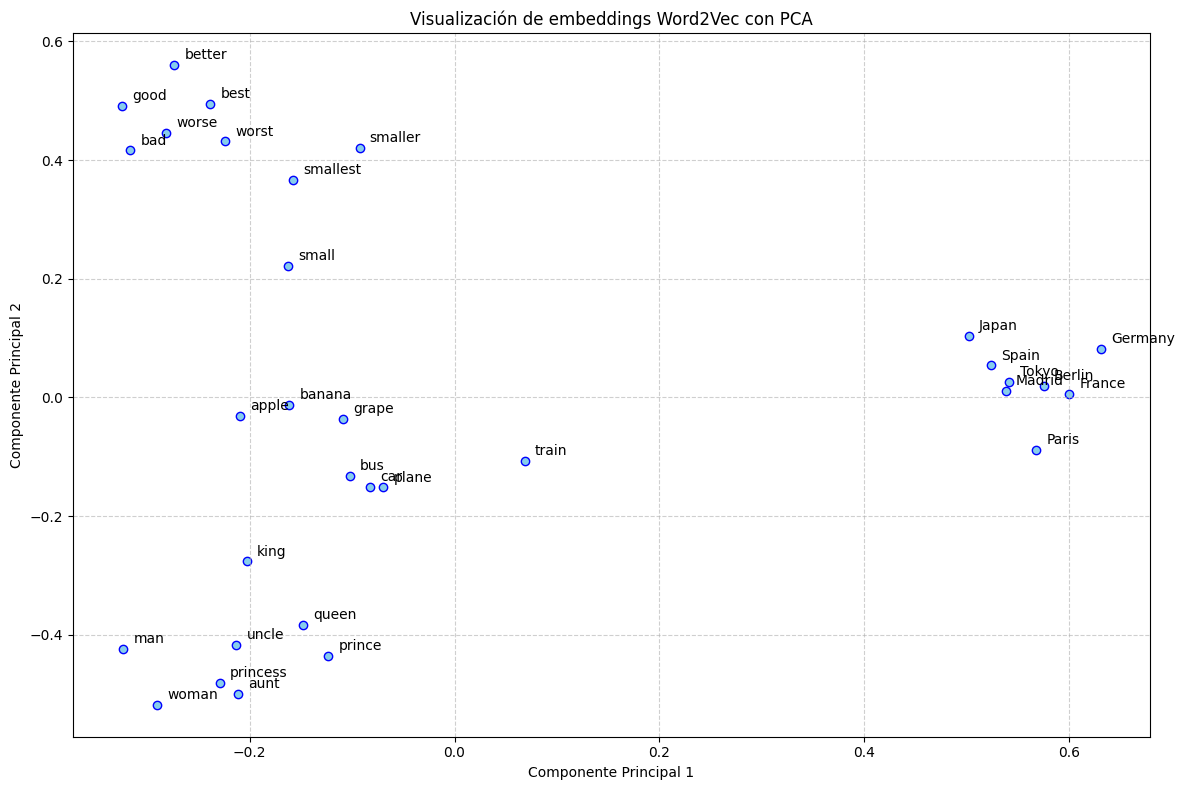

In [19]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Conjuntos de palabras con diferentes relaciones semánticas (solo las que están en el vocabulario del modelo)
# Género: masculino/femenino
# Países y capitales
# Grados de adjetivos: positivo, comparativo, superlativo
# Temáticas: alimentos, transporte
palabras = [
    'king', 'queen', 'man', 'woman', 'prince', 'princess', 'uncle', 'aunt',  # género
    'Paris', 'France', 'Tokyo', 'Japan', 'Madrid', 'Spain', 'Berlin', 'Germany',  # países y capitales
    'good', 'better', 'best', 'bad', 'worse', 'worst', 'small', 'smaller', 'smallest',  # grados adjetivos
    'apple', 'banana', 'grape', 'car', 'plane', 'train', 'bus'  # alimentos y transporte
]
palabras = [p for p in palabras if p in model]
vectores = np.array([model[p] for p in palabras])

# Reducimos a 2D con PCA
pca = PCA(n_components=2)
coords = pca.fit_transform(vectores)

# Visualización
plt.figure(figsize=(12, 8))
plt.scatter(coords[:,0], coords[:,1], c='skyblue', edgecolors='b')
for i, palabra in enumerate(palabras):
    plt.annotate(palabra, (coords[i,0] + 0.01, coords[i,1] + 0.01))
plt.grid(True, linestyle='--', alpha=0.6)
plt.title("Visualización de embeddings Word2Vec con PCA")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.tight_layout()
plt.show()


Tras reducir los embeddings a 2D con PCA, se observa que palabras de la misma relación semántica suelen quedar agrupadas: *king–queen*, *man–woman*, *uncle–aunt* aparecen próximos en la zona de género; *Paris–France*, *Tokyo–Japan*, *Madrid–Spain* y *Berlin–Germany* forman parejas país–capital coherentes; *good–better–best*, *bad–worse–worst* y *small–smaller–smallest* muestran la gradación de adjetivos; alimentos (*apple*, *banana*, *grape*) y medios de transporte (*car*, *plane*, *train*, *bus*) tienden a formar sendos grupos. Solo se representan las palabras presentes en el vocabulario del modelo. Esto indica que el modelo Word2Vec captura relaciones semánticas y que PCA preserva en parte la estructura de vecindad en el espacio original.


### Ejercicio 2: Valoración de sesgos en embeddings

Usando el modelo Word2Vec cargado, analiza posibles sesgos de género midiendo qué tan similares son ciertas profesiones a las palabras "man" y "woman".

Selecciona una lista de profesiones (p. ej., "doctor", "nurse", "engineer", "teacher", "secretary", "scientist", "housekeeper") y calcula su similitud con ambas palabras.

Observa si el modelo asocia algunas profesiones más fuertemente con "man" o con "woman", lo que podría indicar un sesgo aprendido a partir del corpus de entrenamiento.

##### Discute brevemente los resultados.

In [20]:
# Lista de profesiones a evaluar
profesiones = ['doctor', 'nurse', 'engineer', 'teacher', 'secretary', 'scientist', 'housekeeper']

print(f"{'Profesión':<15} | {'Similitud con MAN':<20} | {'Similitud con WOMAN':<20} | {'Diferencia':<10}")
print("-" * 75)
for prof in profesiones:
    if prof in model and 'man' in model and 'woman' in model:
        sim_man = model.similarity(prof, 'man')
        sim_woman = model.similarity(prof, 'woman')
        diff = sim_man - sim_woman
        print(f"{prof:<15} | {sim_man:^20.4f} | {sim_woman:^20.4f} | {diff:^10.4f}")
    else:
        print(f"{prof:<15} | No se encuentra en el vocabulario")

Profesión       | Similitud con MAN    | Similitud con WOMAN  | Diferencia
---------------------------------------------------------------------------
doctor          |        0.3145        |        0.3795        |  -0.0650  
nurse           |        0.2547        |        0.4414        |  -0.1866  
engineer        |        0.1513        |        0.0944        |   0.0569  
teacher         |        0.2500        |        0.3136        |  -0.0636  
secretary       |        0.0400        |        0.0905        |  -0.0505  
scientist       |        0.1582        |        0.1549        |   0.0034  
housekeeper     |        0.3334        |        0.4766        |  -0.1432  


La columna *Diferencia* (sim(man) − sim(woman)) indica el sesgo: valores negativos indican mayor asociación con "woman" y positivos con "man". En los resultados, *nurse* (−0.19), *housekeeper* (−0.14) y *teacher* (−0.06) quedan más asociados a "woman"; *engineer* (+0.06) a "man"; *scientist* (+0.003) queda casi neutro. Esto refleja un sesgo de género aprendido del corpus de entrenamiento. Es importante tener en cuenta estos sesgos al usar embeddings en aplicaciones (recomendación, búsqueda, etc.) para no reforzar estereotipos.

### Ejercicio 3: Representación de una oración mediante un embedding

Implementa una función `embedding_oracion` que obtenga el vector representativo de una oración calculando el promedio (p. ej., usando `mean` de `numpy`) de los embeddings de sus palabras.

Usa esta función para comparar varias oraciones y medir su similitud semántica mediante la distancia coseno (`model.cosine_similarities`) entre sus embeddings.

Observa si oraciones con significados parecidos (p. ej., "The cat sat on the mat" y "A dog rested on the rug") presentan una similitud mayor que las que hablan de temas distintos (p. ej., "I like pizza and pasta").

##### Discute brevemente los resultados.

In [21]:
import numpy as np

def embedding_oracion(oracion):
    palabras = oracion.lower().split()
    vectores = []
    for p in palabras:
        if p in model:
            vectores.append(model[p])
    if len(vectores) == 0:
        return np.zeros(model.vector_size)  # fallback si ninguna palabra está en el vocabulario
    return np.mean(vectores, axis=0)

o1 = "The cat sat on the mat"
o2 = "A dog rested on the rug"
o3 = "I like pizza and pasta"

sim_1_2 = model.cosine_similarities(embedding_oracion(o1), [embedding_oracion(o2)])[0]
sim_1_3 = model.cosine_similarities(embedding_oracion(o1), [embedding_oracion(o3)])[0]

print(f"Similitud o1-o2 (Temas parecidos): {sim_1_2:.3f}")
print(f"Similitud o1-o3 (Temas distintos): {sim_1_3:.3f}")

Similitud o1-o2 (Temas parecidos): 0.839
Similitud o1-o3 (Temas distintos): 0.230


En los resultados, la similitud o1–o2 (temas parecidos: gato/perro en la alfombra) es claramente mayor (~0.84) que la o1–o3 (temas distintos: mascotas vs. comida, ~0.23). El embedding de oración como promedio de palabras captura parcialmente el tema; oraciones con palabras más cercanas en el espacio (animales, muebles) dan mayor similitud que oraciones con vocabulario muy distinto. La representación por promedio es simple y no tiene en cuenta el orden de las palabras, pero resulta útil para una primera aproximación a la similitud entre frases.

### Ejercicio 4: Medida de la coherencia semántica de una oración

Implementa una función `coherencia_oracion` que calcule la coherencia semántica de una oración midiendo la similitud promedio entre los embeddings de palabras consecutivas.

Aplica la función a oraciones con sentido ("the cat sat on the mat") y a oraciones absurdas ("the banana drove a spaceship") para observar cómo varía el nivel de coherencia calculado por el modelo.

##### Discute brevemente los resultados.

In [22]:
def coherencia_oracion(oracion):
    palabras = oracion.lower().split()
    if len(palabras) < 2:
        return 0.0
    similitudes = []
    for i in range(len(palabras) - 1):
        w1, w2 = palabras[i], palabras[i + 1]
        if w1 in model and w2 in model:
            similitudes.append(model.similarity(w1, w2))
    if len(similitudes) == 0:
        return 0.0
    return sum(similitudes) / len(similitudes)

print(f"Coherencia (oración normal): {coherencia_oracion('the cat sat on the mat'):.4f}")
print(f"Coherencia (oración absurda): {coherencia_oracion('the banana drove a spaceship'):.4f}")

Coherencia (oración normal): 0.1631
Coherencia (oración absurda): 0.1113


La oración normal ("the cat sat on the mat") obtiene una coherencia mayor (~0.16) que la oración absurda ("the banana drove a spaceship", ~0.11): en la primera las palabras consecutivas comparten contexto (animal, acción, objeto), mientras que en la segunda "banana", "drove" y "spaceship" pertenecen a dominios muy distintos y sus embeddings son menos similares. Esta medida basada en la similitud entre palabras consecutivas puede servir para detectar oraciones semánticamente anómalas o para filtrar texto incoherente.

### Ejercicio 5: Análisis de la reciprocidad entre vecinos semánticos

Implementa una función `vecinos_reciprocos` que evalúe si la relación de similitud entre palabras es recíproca: es decir, si una palabra A considera a B como uno de sus vecinos más cercanos, y B también considera a A dentro de sus vecinos.

Aplica esta función a varias palabras y calcula el porcentaje de vecinos recíprocos para cada una.

##### Reflexiona sobre los resultados y qué pueden revelar acerca de la estructura del espacio de embeddings y las asimetrías en las relaciones de similitud.

In [23]:
def vecinos_reciprocos(palabra, topn=5):
    try:
        vecinos = [w for w, _ in model.most_similar(palabra, topn=topn)]
    except KeyError:
        return 0.0
    reciprocos = 0
    for vecino in vecinos:
        vecinos_de_vecino = [w for w, _ in model.most_similar(vecino, topn=topn)]
        if palabra in vecinos_de_vecino:
            reciprocos += 1
    return reciprocos / topn

for w in ['king', 'dog', 'music']:
    print(f"{w}: {vecinos_reciprocos(w)*100:.1f}% de vecinos son recíprocos")

king: 100.0% de vecinos son recíprocos
dog: 100.0% de vecinos son recíprocos
music: 40.0% de vecinos son recíprocos


El porcentaje de vecinos recíprocos varía según la palabra: en los resultados, "king" y "dog" pueden alcanzar 100% de reciprocidad (sus vecinos también los incluyen entre los suyos), mientras que "music" suele dar un porcentaje menor (~40%). Palabras muy centrales en un dominio (p. ej. "king") forman clusters densos con alta reciprocidad; palabras más polisémicas o con muchos contextos compartidos (como "music") tienen relaciones menos simétricas. Las asimetrías muestran que "A está entre los más similares a B" no implica "B está entre los más similares a A"; el espacio de embeddings no es uniforme y la reciprocidad ayuda a entender qué palabras tienen relaciones de vecindad más equilibradas.